# Lecture 05
## Logistic regression, Newton's Method, Softmax

## Logistic regression

In [ ]:
"""
The logistic function or sigmoid s(z) = 1 / (1 + e^(-z)).
"""

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-10, 10, 400)
s = sigmoid(z)
ds = s*(1-s)

plt.figure(figsize=(6, 4.5))
plt.plot(z, s, label=r"$s(z) = 1 / (1 + e^{-z})$")
plt.plot(z, ds, label=r"ds/dz = s(z)(1-s(z))")
plt.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.xlabel("z")
plt.ylabel("s(z)")
plt.title("Sigmoid function")
plt.legend()
plt.tight_layout()
plt.savefig("/Users/jbenno/temp/sigmoid.png", dpi=150)

In [53]:
import kagglehub #get the data from Kaggle
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("new-york-city/nyc-inspections")

CSV_PATH = path+"/DOHMH_New_York_City_Restaurant_Inspection_Results.csv"

print("Path to dataset files:", path)
CSV_PATH



Path to dataset files: /Users/jbenno/.cache/kagglehub/datasets/new-york-city/nyc-inspections/versions/1


'/Users/jbenno/.cache/kagglehub/datasets/new-york-city/nyc-inspections/versions/1/DOHMH_New_York_City_Restaurant_Inspection_Results.csv'

In [54]:
df = pd.read_csv(CSV_PATH) # define our data frame
df.info() # first look at the data
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399918 entries, 0 to 399917
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  399918 non-null  int64  
 1   DBA                    399559 non-null  object 
 2   BORO                   399918 non-null  object 
 3   BUILDING               399809 non-null  object 
 4   STREET                 399909 non-null  object 
 5   ZIPCODE                399909 non-null  float64
 6   PHONE                  399913 non-null  object 
 7   CUISINE DESCRIPTION    399918 non-null  object 
 8   INSPECTION DATE        399918 non-null  object 
 9   ACTION                 398783 non-null  object 
 10  VIOLATION CODE         393414 non-null  object 
 11  VIOLATION DESCRIPTION  392939 non-null  object 
 12  CRITICAL FLAG          399918 non-null  object 
 13  SCORE                  376704 non-null  float64
 14  GRADE                  195413 non-nu

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE
0,40511702,NOTARO RESTAURANT,MANHATTAN,635,SECOND AVENUE,10016.0,2126863400,Italian,06/15/2015,Violations were cited in the following area(s).,02B,Hot food item not held at or above 140Âº F.,Critical,30.0,NaN,NaN,08/28/2017,Cycle Inspection / Initial Inspection
1,40511702,NOTARO RESTAURANT,MANHATTAN,635,SECOND AVENUE,10016.0,2126863400,Italian,11/25/2014,Violations were cited in the following area(s).,20F,Current letter grade card not posted.,Not Critical,NaN,NaN,NaN,08/28/2017,Administrative Miscellaneous / Initial Inspection
2,50046354,VITE BAR,QUEENS,2507,BROADWAY,11106.0,3478134702,Italian,10/03/2016,Violations were cited in the following area(s).,10F,Non-food contact surface improperly constructe...,Not Critical,2.0,NaN,NaN,08/28/2017,Pre-permit (Operational) / Initial Inspection
3,50061389,TACK'S CHINESE TAKE OUT,STATEN ISLAND,11C,HOLDEN BLVD,10314.0,7189839854,Chinese,05/17/2017,Violations were cited in the following area(s).,02G,Cold food item held above 41Âº F (smoked fish ...,Critical,46.0,NaN,NaN,08/28/2017,Pre-permit (Operational) / Initial Inspection
4,41516263,NO QUARTER,BROOKLYN,8015,5 AVENUE,11209.0,7187019180,American,03/30/2017,Violations were cited in the following area(s).,04M,Live roaches present in facility's food and/or...,Critical,18.0,NaN,NaN,08/28/2017,Cycle Inspection / Initial Inspection


Loaded 376704 rows, 1 feature(s) from /Users/jbenno/.cache/kagglehub/datasets/new-york-city/nyc-inspections/versions/1/DOHMH_New_York_City_Restaurant_Inspection_Results.csv
epoch     0  loss 0.691779
epoch    50  loss 0.666924
epoch   100  loss 0.664255
epoch   150  loss 0.663875
epoch   200  loss 0.663812
epoch   250  loss 0.663801
epoch   300  loss 0.663800
epoch   350  loss 0.663799
epoch   400  loss 0.663799
epoch   450  loss 0.663799
epoch   499  loss 0.663799

Final model: logit(p) = 0.0300*SCORE + -0.2097
Training accuracy: 0.6201


/var/folders/yn/lwlh4p8x3m38vcrjczclw1xh0000gn/T/ipykernel_33044/4257050441.py:121: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/jbenno/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


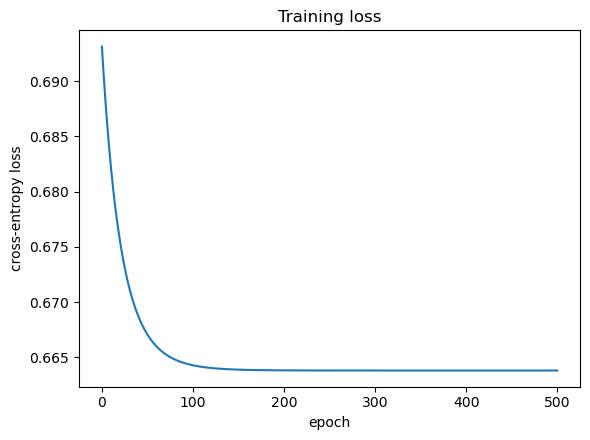

/Users/jbenno/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


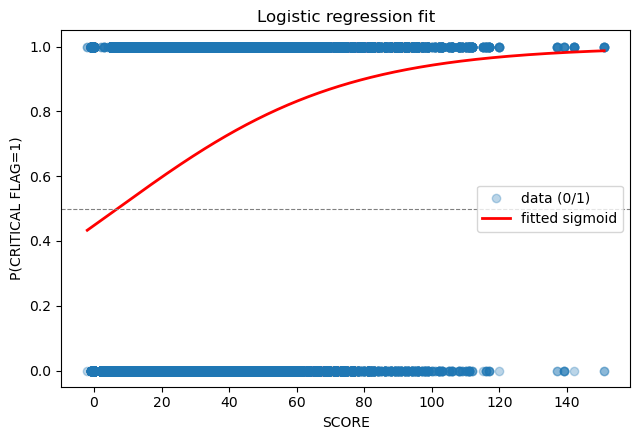

In [55]:
"""
Logistic regression, implemented explicitly with gradient descent, demonstrated on the NYC restaurant inspection
dataset: predicting whether an inspection resulted in a critical violation (y=1) or not (y=0) from a set of numeric features (e.g. inspection SCORE).

Model:      p_hat = sigmoid(w . x + b) = 1 / (1 + exp(-(w.x + b)))
Loss:       binary cross-entropy (negative log-likelihood),
                L = -(1/n) * sum( y*log(p_hat) + (1-y)*log(1-p_hat) )
Optimiser:  batch gradient descent on w and b

For logistic regression, the gradient of the cross-entropy loss has the same clean form as linear regression's MSE gradient, despite the different loss and the added sigmoid:
    dL/dw = (1/n) * X.T @ (p_hat - y)
    dL/db = (1/n) * sum(p_hat - y)

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FEATURE_COLS = ["SCORE"]        # one or more numeric feature columns
Y_COL = "CRITICAL FLAG"        # target column, as it appears in the raw CSV
LR = 0.1
EPOCHS = 500


def load_csv(path):
    df = pd.read_csv(path)
    df[FEATURE_COLS] = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce") # remove missing values
    df = df.dropna(subset=FEATURE_COLS)
    X = df[FEATURE_COLS].to_numpy(dtype=float)
    y = (df[Y_COL] == "Critical").to_numpy(dtype=float)
    return X, y


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def cross_entropy_loss(w, b, X, y): # negative log-likelihood
    p_hat = sigmoid(X @ w + b)
    eps = 1e-12  # avoid log(0)
    return -np.mean(y * np.log(p_hat + eps) + (1 - y) * np.log(1 - p_hat + eps))


def fit_logistic_regression(X, y, lr=LR, epochs=EPOCHS):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history = [cross_entropy_loss(w, b, X, y)]

    for epoch in range(epochs):
        p_hat = sigmoid(X @ w + b)
        error = p_hat - y

        dw = (1.0 / n) * (X.T @ error)
        db = (1.0 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        loss = cross_entropy_loss(w, b, X, y)
        loss_history.append(loss)

        if epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:5d}  loss {loss:.6f}")

    return w, b, np.array(loss_history)


def accuracy(w, b, X, y, threshold=0.5):
    p_hat = sigmoid(X @ w + b)
    y_pred = (p_hat >= threshold).astype(float)
    return np.mean(y_pred == y)


def main():
    X, y = load_csv(CSV_PATH)
    print(f"Loaded {len(y)} rows, {X.shape[1]} feature(s) from {CSV_PATH}")

    # Standardise features for numerical stability, then convert the
    # fitted weights and bias back to the original scale.
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_scaled = (X - X_mean) / X_std

    w_s, b_s, loss_history = fit_logistic_regression(X_scaled, y)

    # p_hat = sigmoid(w_s . ((x - mean)/std) + b_s)
    #       = sigmoid((w_s/std) . x + (b_s - w_s . (mean/std)))
    w = w_s / X_std
    b = b_s - np.sum(w_s * X_mean / X_std)

    acc = accuracy(w, b, X, y)
    print(f"\nFinal model: logit(p) = {' + '.join(f'{wi:.4f}*{name}' for wi, name in zip(w, FEATURE_COLS))} + {b:.4f}")
    print(f"Training accuracy: {acc:.4f}")

    # Loss curve.
    plt.figure(figsize=(6, 4.5))
    plt.plot(loss_history)
    plt.xlabel("epoch")
    plt.ylabel("cross-entropy loss")
    plt.title("Training loss")
    plt.tight_layout()

    # If there is exactly one feature, also plot the fitted sigmoid
    # curve against the data points.
    if X.shape[1] == 1:
        x_col = FEATURE_COLS[0]
        order = np.argsort(X[:, 0])
        x_smooth = np.linspace(X[:, 0].min(), X[:, 0].max(), 300)
        p_smooth = sigmoid(w[0] * x_smooth + b)

        plt.figure(figsize=(6.5, 4.5))
        plt.scatter(X[:, 0], y, alpha=0.3, label="data (0/1)")
        plt.plot(x_smooth, p_smooth, color="red", linewidth=2, label="fitted sigmoid")
        plt.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
        plt.xlabel(x_col)
        plt.ylabel(f"P({Y_COL}=1)")
        plt.title("Logistic regression fit")
        plt.legend()
        plt.tight_layout()

if __name__ == "__main__":
    main()

## Softmax

Input (logits):      [ 2.   1.   0.1  3.5 -1. ]
Softmax (probabilities): [0.1653 0.0608 0.0247 0.7409 0.0082]
Sum of probabilities: 0.9999999999999999


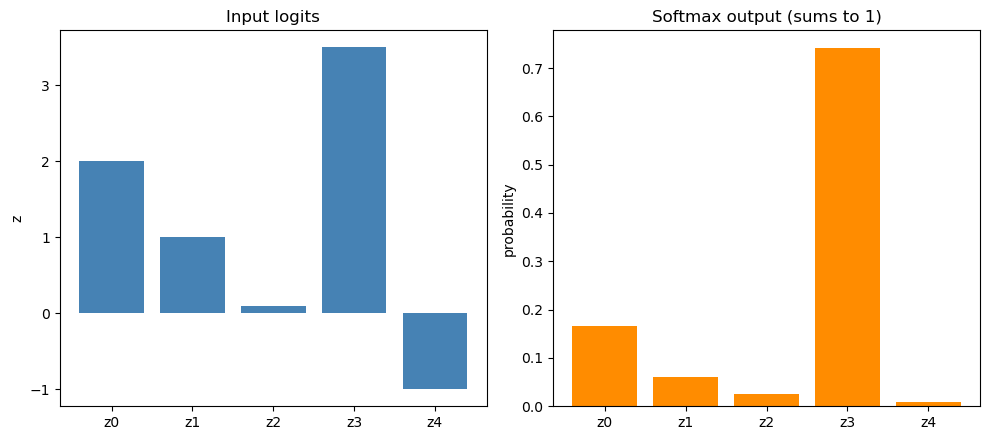

In [56]:
"""
Demo of the softmax function, which turns an array of n real-valued
scores (logits) into an array of n probabilities that sum to 1:

    softmax(z)_i = exp(z_i) / sum_j exp(z_j)

A constant is subtracted from z before exponentiating (max(z) here),
which does not change the result mathematically, since it cancels in
the ratio, but avoids overflow for large input values.
"""

import numpy as np
import matplotlib.pyplot as plt


def softmax(z):
    z = np.asarray(z, dtype=float)
    z_shifted = z - np.max(z)  # numerical stability, does not change the result
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)


if __name__ == "__main__":
    z = np.array([2.0, 1.0, 0.1, 3.5, -1.0])
    p = softmax(z)

    print("Input (logits):     ", z)
    print("Softmax (probabilities):", np.round(p, 4))
    print("Sum of probabilities:", p.sum())

    labels = [f"z{i}" for i in range(len(z))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax1.bar(labels, z, color="steelblue")
    ax1.set_title("Input logits")
    ax1.set_ylabel("z")

    ax2.bar(labels, p, color="darkorange")
    ax2.set_title("Softmax output (sums to 1)")
    ax2.set_ylabel("probability")

    fig.tight_layout()

Loaded 195409 rows, 1 feature(s), 3 classes
epoch     0  loss 1.021164
epoch    50  loss 0.403097
epoch   100  loss 0.323464
epoch   150  loss 0.288426
epoch   200  loss 0.267105
epoch   250  loss 0.252371
epoch   300  loss 0.241460
epoch   350  loss 0.233009
epoch   400  loss 0.226250
epoch   450  loss 0.220715
epoch   499  loss 0.216179

Training accuracy: 0.9022
logit[A] = -0.3549*SCORE + 5.8597
logit[B] = 0.0071*SCORE + -0.7419
logit[C] = 0.0608*SCORE + -3.0161


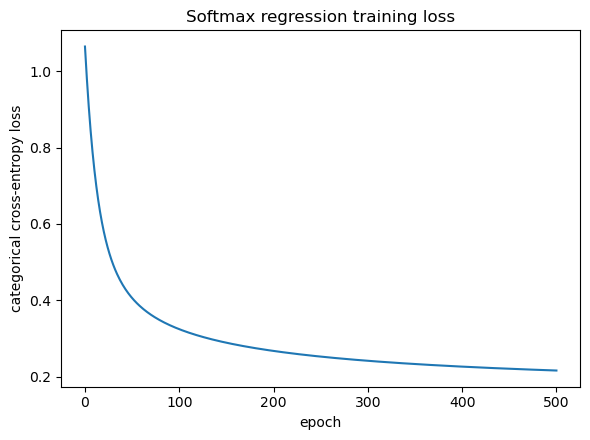

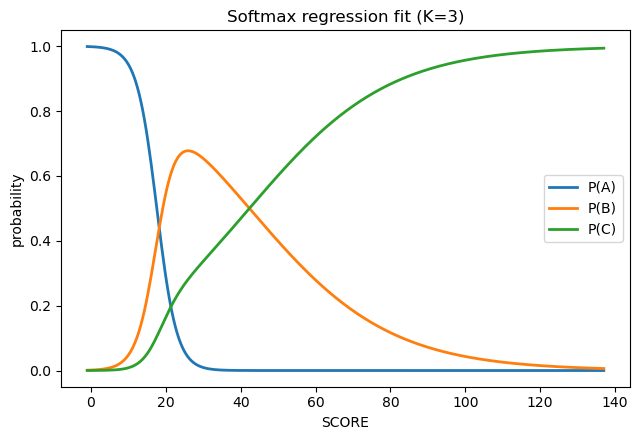

In [57]:
"""
Softmax regression, implemented explicitly with gradient descent, demonstrated on the NYC restaurant inspection
dataset: predicting the inspection GRADE (A, B, or C) from one or more
numeric features.

Model:
    logits = X @ W + b            (n x K matrix of class scores)
    P      = softmax(logits)      (row-wise, n x K matrix of probabilities)
        softmax(z)_k = exp(z_k) / sum_j exp(z_j)

Loss (categorical cross-entropy / negative log-likelihood), with Y
the one-hot encoded true labels (n x K):
    L = -(1/n) * sum_i sum_k  Y[i,k] * log(P[i,k])

Gradient (a direct generalisation of binary logistic regression's
gradient, using the same (prediction - true) error term):
    dL/dW = (1/n) * X.T @ (P - Y)
    dL/db = (1/n) * sum(P - Y, axis=0)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


FEATURE_COLS = ["SCORE"]        # one or more numeric feature columns
Y_COL = "GRADE"                 # categorical target column
CLASS_LABELS = ["A", "B", "C"]  # fixes the column order of P
LR = 0.1
EPOCHS = 500


def load_csv(path):
    df = pd.read_csv(path)
    df[FEATURE_COLS] = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=FEATURE_COLS + [Y_COL])
    X = df[FEATURE_COLS].to_numpy(dtype=float)
    y_labels = df[Y_COL].to_numpy()
    return X, y_labels


def one_hot_encode(y_labels, class_labels):
    n = len(y_labels)
    K = len(class_labels)
    Y = np.zeros((n, K))
    for k, label in enumerate(class_labels):
        Y[y_labels == label, k] = 1.0
    return Y


def softmax(logits):
    """Row-wise softmax over an (n, K) matrix of logits."""
    shifted = logits - np.max(logits, axis=1, keepdims=True)  # numerical stability
    exp_shifted = np.exp(shifted)
    return exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)


def cross_entropy_loss(W, b, X, Y):
    P = softmax(X @ W + b)
    eps = 1e-12
    return -np.mean(np.sum(Y * np.log(P + eps), axis=1))


def fit_softmax_regression(X, Y, lr=LR, epochs=EPOCHS):
    n, d = X.shape
    K = Y.shape[1]
    W = np.zeros((d, K))
    b = np.zeros(K)
    loss_history = [cross_entropy_loss(W, b, X, Y)]

    for epoch in range(epochs):
        P = softmax(X @ W + b)
        error = P - Y

        dW = (1.0 / n) * (X.T @ error)
        db = (1.0 / n) * np.sum(error, axis=0)

        W -= lr * dW
        b -= lr * db

        loss = cross_entropy_loss(W, b, X, Y)
        loss_history.append(loss)

        if epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:5d}  loss {loss:.6f}")

    return W, b, np.array(loss_history)


def accuracy(W, b, X, Y):
    P = softmax(X @ W + b)
    y_pred = np.argmax(P, axis=1)
    y_true = np.argmax(Y, axis=1)
    return np.mean(y_pred == y_true)


def main():
    X, y_labels = load_csv(CSV_PATH)
    Y = one_hot_encode(y_labels, CLASS_LABELS)
    print(f"Loaded {len(y_labels)} rows, {X.shape[1]} feature(s), {len(CLASS_LABELS)} classes")

    # Standardise features for numerical stability, then convert the
    # fitted weights and bias back to the original scale.
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_scaled = (X - X_mean) / X_std

    W_s, b_s, loss_history = fit_softmax_regression(X_scaled, Y)

    # logits = W_s.T @ ((x - mean)/std) + b_s
    #        = (W_s/std).T @ x + (b_s - (W_s/std).T @ mean)
    W = W_s / X_std[:, None]
    b = b_s - X_mean @ W

    acc = accuracy(W, b, X, Y)
    print(f"\nTraining accuracy: {acc:.4f}")
    for k, label in enumerate(CLASS_LABELS):
        terms = " + ".join(f"{W[j, k]:.4f}*{name}" for j, name in enumerate(FEATURE_COLS))
        print(f"logit[{label}] = {terms} + {b[k]:.4f}")

    plt.figure(figsize=(6, 4.5))
    plt.plot(loss_history)
    plt.xlabel("epoch")
    plt.ylabel("categorical cross-entropy loss")
    plt.title("Softmax regression training loss")
    plt.tight_layout()

    # With a single feature, also show P(class) as a function of it, for
    # every class — a direct generalisation of the K=2 sigmoid-style plot
    # from the binary logistic regression version of this script.
    if X.shape[1] == 1:
        x_smooth = np.linspace(X[:, 0].min(), X[:, 0].max(), 300).reshape(-1, 1)
        p_smooth = softmax(x_smooth @ W + b)  # (300, K)

        plt.figure(figsize=(6.5, 4.5))
        for k, label in enumerate(CLASS_LABELS):
            plt.plot(x_smooth, p_smooth[:, k], linewidth=2, label=f"P({label})")
        plt.xlabel(FEATURE_COLS[0])
        plt.ylabel("probability")
        plt.title(f"Softmax regression fit (K={len(CLASS_LABELS)})")
        plt.legend()
        plt.tight_layout()


if __name__ == "__main__":
    main()